In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys
import os

# Add work directory to path
sys.path.insert(0, '/home/svu/e1498138/emri_search/work')
import GWfuncs
import loglike_timemax
import loglike_timemax_Xonly


# Import from few
from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux
import few

# Tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu=True
force_backend = 'cuda12x'
# Inspiral kwargs
inspiral_kwargs = {
    "func": 'KerrEccEqFlux',
    "DENSE_STEPPING": 0,
    "include_minus_m": False,
}

# Amplitude kwargs
amplitude_kwargs = {
    "force_backend": force_backend
}

# Ylm kwargs
Ylm_kwargs = {
    "force_backend": force_backend,
}

# Sum kwargs
sum_kwargs_comb = {
    "force_backend": force_backend,
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,
    "pad_output": True,
    "separate_modes": True,
}

# Create waveform generators
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux,
    frame='detector',
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)



In [24]:
# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = np.array([np.log10(m1), np.log10(m2), a, p0, e0])

In [25]:
#3mth
T = 3/12 
dt = 10
gwf = GWfuncs.GravWaveAnalysis(T, dt)

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_tm = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=True,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

Initializing LogLike...
Delta_T for mode selection: 1577.9074881772797 seconds
Generating modes at initialization...
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Numbe

In [26]:
print('Initializing LogLike...')
loglike_tmX = loglike_timemax_Xonly.LogLike(
    params_star, waveform_gen_comb, gwf,
    verbose=False, waveform_gen_sep=waveform_gen_sep,
    ell=ell, n_vals=n_vals, M_mode=None,
)

Initializing LogLike...


In [27]:
def logden_tm(params):
      logm1, logm2, a, p0, e0 = params
      return float(loglike_tm(np.array([10**logm1, 10**logm2, a, p0, e0,
                                        xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0])))

In [28]:
def logden_pure(params):
    logm1, logm2, a, p0, e0 = params
    return float(loglike_tmX(np.array([10**logm1, 10**logm2, a, p0, e0,
                                        xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0])))

In [29]:
logden_pure(param_true), logden_tm(param_true)

Evaluating log-likelihood at parameters: [1.00000000e+06 1.00000000e+01 7.00000000e-01 9.00000000e+00
 4.00000000e-01 1.00000000e+00 1.80000000e+00 3.14159265e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 4.00000000e-01
 0.00000000e+00 5.00000000e-01]
Using selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Waveform amplitudes (time-maximized):
  Mode 0: max(|h|) = 4.192198513129151e-23, <hf|hf>_timemax = 0.03705087204221812, rho = 0.1924860307716332
  Mode 1: max(|h|) = 3.842269848273444e-23, <hf|hf>_timemax = 0.10284393979913493, rho = 0.32069290575117954
  Mode 2: max(|h|) = 5.495252674074348e-23, <hf|

(5.907162614839672, 5.907121463459377)

In [30]:
data_fd = np.fft.rfft(loglike_tm.signal)
data_fd

/nfs/home/svu/e1498138/emri_search_uv/.venv/lib64/python3.9/site-packages/cupy/fft/_fft.py:35: ComplexWarning: Casting complex values to real discards the imaginary part
  a = a.astype(out_dtype)


array([1.00475434e-21+0.00000000e+00j, 1.00475434e-21+3.79337278e-26j,
       1.00475434e-21+7.58670212e-26j, ...,
       8.83663860e-23-7.66980034e-28j, 8.83663863e-23-3.83617575e-28j,
       8.83663864e-23+0.00000000e+00j])

In [31]:
# gwf_2yr = GWfuncs.GravWaveAnalysis(T=2, dt=10)
# loglike_obj_2yr = loglikegen.LogLike(params_star,
#                                     waveform_gen_comb,
#                                     gwf_2yr,
#                                     mode_select=mode_select,
#                                     verbose=False,
#                                     waveform_gen_sep=waveform_gen_sep)

In [32]:
param_idx = 1  # logm2
true_val = param_true[param_idx]

param_range = np.sort(np.append(np.linspace(0.99,1.01, 100), true_val))

f_stats_tm   = np.zeros(len(param_range))
f_stats_pure = np.zeros(len(param_range))
lnL_vals     = np.zeros(len(param_range))

m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0 = params_star

for i, val in enumerate(param_range):
    p = param_true.copy()
    p[param_idx] = val
    f_stats_tm[i]   = logden_tm(p)
    f_stats_pure[i] = logden_pure(p)
    lnL_vals[i]     = standard_lnL(p, loglike_tm.signal, gwf, waveform_gen_comb,
                                    xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)

Evaluating log-likelihood at parameters: [1.00000000e+06 9.77237221e+00 7.00000000e-01 9.00000000e+00
 4.00000000e-01 1.00000000e+00 1.80000000e+00 3.14159265e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 4.00000000e-01
 0.00000000e+00 5.00000000e-01]
Using selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Waveform amplitudes (time-maximized):
  Mode 0: max(|h|) = 4.094407916340241e-23, <hf|hf>_timemax = 0.03525704876613864, rho = 0.18776860431429596
  Mode 1: max(|h|) = 3.743622569495829e-23, <hf|hf>_timemax = 0.09773973834118489, rho = 0.3126335528077319
  Mode 2: max(|h|) = 5.363256775921046e-23, <hf|

In [33]:
# Normalize computed F-stat to peak at 0
f_stats_tm_norm = f_stats_tm - np.max(f_stats_tm)
f_stats_pure_norm = f_stats_pure - np.max(f_stats_pure)

lnL_norm = lnL_vals - np.max(lnL_vals)

/var/tmp/pbs.483164.hopper-m-02/ipykernel_2636739/776299352.py:5: RuntimeWarning: invalid value encountered in subtract
  lnL_norm = lnL_vals - np.max(lnL_vals)


In [34]:
f_stats_tm

array([0.39451264, 0.4004967 , 0.4033136 , 0.41815674, 0.42639075,
       0.42824419, 0.44059936, 0.44899568, 0.45644904, 0.45728352,
       0.47253817, 0.48112213, 0.48412631, 0.49710957, 0.51036461,
       0.52229395, 0.53023167, 0.54409994, 0.56403406, 0.57737958,
       0.58856921, 0.61509227, 0.63665431, 0.65452967, 0.67084861,
       0.71453269, 0.74057664, 0.74137258, 0.78416593, 0.82636603,
       0.85033652, 0.85984362, 0.93068236, 0.98959381, 1.01937232,
       1.0837816 , 1.17345038, 1.25420991, 1.34806871, 1.4347199 ,
       1.60333581, 1.82424503, 2.05654415, 2.18215956, 2.54934021,
       3.46473809, 4.3458634 , 5.18246303, 5.68672736, 5.76157028,
       5.90712146, 5.76212554, 5.6868514 , 5.17733182, 4.33308493,
       3.44290131, 2.52528176, 2.1647417 , 2.03306145, 1.79729628,
       1.57608805, 1.40747553, 1.32246387, 1.22879562, 1.14480798,
       1.05291191, 0.99482933, 0.96143023, 0.89761649, 0.82902752,
       0.82663034, 0.79235985, 0.75078845, 0.71675534, 0.70871

In [35]:
f_stats_pure

array([0.23622776, 0.23720689, 0.23869966, 0.24784593, 0.2461332 ,
       0.25410259, 0.2542604 , 0.25719517, 0.26528328, 0.25996109,
       0.26792213, 0.27222833, 0.27180748, 0.27771151, 0.28344279,
       0.2855393 , 0.29260282, 0.29619664, 0.29895074, 0.31649542,
       0.3073902 , 0.323431  , 0.33586071, 0.33468281, 0.34628319,
       0.3612007 , 0.36955375, 0.37286188, 0.38407196, 0.39689514,
       0.40993232, 0.40733966, 0.43044723, 0.46147424, 0.44295444,
       0.50188349, 0.50234728, 0.52458936, 0.58145057, 0.57973701,
       0.63711675, 0.71093398, 0.76376742, 0.82936762, 0.93793537,
       1.1339902 , 1.55351605, 1.77325632, 2.09282785, 5.64059427,
       5.90716261, 5.65522432, 2.1208981 , 1.78177463, 1.55710553,
       1.13256675, 0.93417289, 0.8253492 , 0.75850084, 0.70412688,
       0.62730091, 0.57230149, 0.57338513, 0.51193825, 0.49719299,
       0.48628161, 0.43437455, 0.4517632 , 0.41484601, 0.39653648,
       0.39885097, 0.38191702, 0.37046803, 0.36037855, 0.35409

In [36]:
f_stats_tm_norm-f_stats_pure_norm

array([0.15832603, 0.16333096, 0.1646551 , 0.17035196, 0.1802987 ,
       0.17418275, 0.18638012, 0.19184166, 0.19120691, 0.19736358,
       0.20465719, 0.20893495, 0.21235997, 0.21943921, 0.22696297,
       0.2367958 , 0.23767   , 0.24794445, 0.26512447, 0.26092531,
       0.28122016, 0.29170242, 0.30083475, 0.31988802, 0.32460658,
       0.35337314, 0.37106404, 0.36855185, 0.40013512, 0.42951205,
       0.44044536, 0.45254511, 0.50027628, 0.52816073, 0.57645904,
       0.58193926, 0.67114425, 0.7296617 , 0.76665928, 0.85502404,
       0.96626021, 1.1133522 , 1.29281787, 1.35283309, 1.611446  ,
       2.33078904, 2.7923885 , 3.40924787, 3.59394067, 0.12101716,
       0.        , 0.10694237, 3.56599446, 3.39559835, 2.77602055,
       2.31037571, 1.59115002, 1.33943365, 1.27460176, 1.09321055,
       0.94882828, 0.83521519, 0.74911989, 0.71689853, 0.64765614,
       0.56667145, 0.56049593, 0.50970819, 0.48281164, 0.43253219,
       0.42782053, 0.41048398, 0.38036156, 0.35641794, 0.35465

In [40]:
np.min(f_stats_tm_norm)

-5.550474503757141

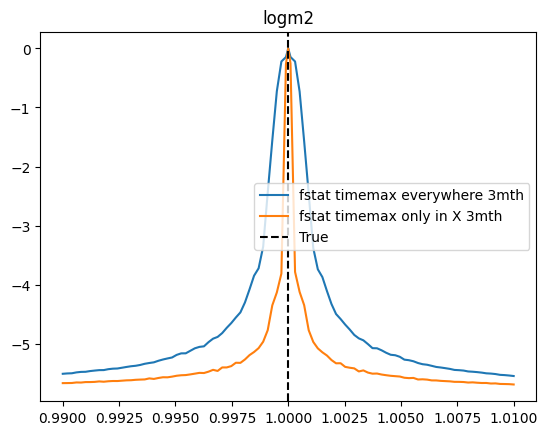

In [39]:
plt.plot(param_range, f_stats_tm_norm, label='fstat timemax everywhere 3mth')
plt.plot(param_range, f_stats_pure_norm, label='fstat timemax only in X 3mth')

# plt.plot(param_range, lnL_vals, label='lnL cond 2 yr')
plt.axvline(1, color='k', linestyle='--', label='True')
# plt.ylim(-5,0.01)
# plt.xlim(0.99999,1.00001)
plt.title('logm2')
plt.legend()
plt.show()